# 02 - Binary Classifier: Will the user purchase?

**Problem**: Session-level feature'lardan purchase (1) / no-purchase (0) tahmini.

**Zorluk**: %3.3 pozitif class.

**Strateji**: `class_weight='balanced'` (LogReg) + `scale_pos_weight` (XGBoost). SMOTE kullanılmıyor — veri hacmi yeterli ve pipeline daha basit kalıyor.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.feature_engineering import FEATURE_COLS

DATA = Path("..") / "data" / "processed"
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

from src.model_binary import split, train_baseline, train_primary, evaluate

## 1. Veriyi yükle

In [2]:
sessions_all = pd.read_parquet(DATA / "sessions_all.parquet")
X = sessions_all[FEATURE_COLS].astype("float32")
y = sessions_all["purchased"].astype("int8")
print(f"X: {X.shape}  y: {y.shape}")
print(f"positive rate: {y.mean():.4f}")

X: (3599496, 14)  y: (3599496,)
positive rate: 0.0332


## 2. Stratified train/test split (80/20, random_state=42)

In [3]:
X_train, X_test, y_train, y_test = split(X, y)
print(f"train: {len(y_train):,}  test: {len(y_test):,}")
print(f"train pos rate: {y_train.mean():.4f}  test pos rate: {y_test.mean():.4f}")

train: 2,879,596  test: 719,900
train pos rate: 0.0332  test pos rate: 0.0332


## 3. Baseline — Logistic Regression

Standardized feature'lar + `class_weight='balanced'`. Lineer sinirli bir model, primary modele kıyaslama noktası.

In [4]:
%time baseline = train_baseline(X_train, y_train)
base_metrics = evaluate(baseline, X_test, y_test)
base_metrics

CPU times: total: 9.73 s
Wall time: 5.47 s


{'f1': 0.2555388325160622,
 'roc_auc': 0.8624438693261243,
 'precision': 0.15837989106994194,
 'recall': 0.6610843625706511,
 'confusion_matrix': {'tn': 612108, 'fp': 83907, 'fn': 8095, 'tp': 15790},
 'n_test': 719900,
 'n_test_positive': 23885}

## 4. Primary — XGBoost

Gradient-boosted trees, `scale_pos_weight = n_neg/n_pos` ile imbalance yönetimi. Non-linear etkileşimleri yakalar.

In [5]:
%time primary = train_primary(X_train, y_train)
prim_metrics = evaluate(primary, X_test, y_test)
prim_metrics

CPU times: total: 6min 27s
Wall time: 32.1 s


{'f1': 0.2966621138824036,
 'roc_auc': 0.9403417187042517,
 'precision': 0.17673277645059401,
 'recall': 0.9230060707557044,
 'confusion_matrix': {'tn': 593319, 'fp': 102696, 'fn': 1839, 'tp': 22046},
 'n_test': 719900,
 'n_test_positive': 23885}

## 5. Model karşılaştırması

In [6]:
def row(m):
    return {"F1": m["f1"], "ROC_AUC": m["roc_auc"],
            "Precision": m["precision"], "Recall": m["recall"]}

comp = pd.DataFrame({"LogReg": row(base_metrics), "XGBoost": row(prim_metrics)}).round(4)
display(comp)

,LogReg,XGBoost
F1,0.2555,0.2967
ROC_AUC,0.8624,0.9403
Precision,0.1584,0.1767
Recall,0.6611,0.9230


## 6. ROC & Precision-Recall eğrileri

ROC-AUC threshold-bağımsız **ranking** performansını ölçer. PR-AUC (AP) imbalanced data'da Accuracy/ROC'tan daha bilgilendirici — base-rate'e göre relatif iyileşme görülebilir.

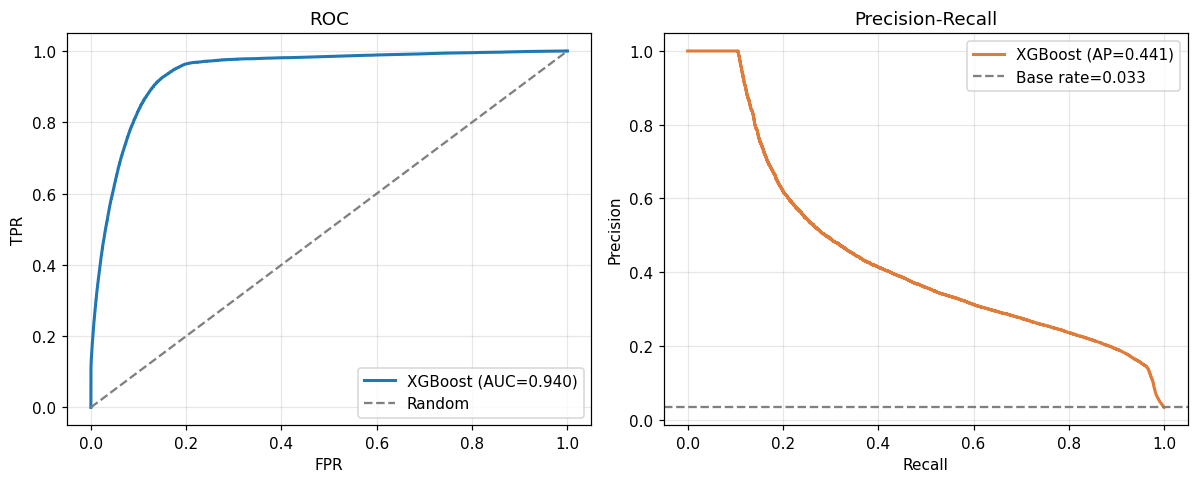

In [7]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

proba = primary.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
prec, rec, _ = precision_recall_curve(y_test, proba)
roc_auc_v = auc(fpr, tpr)
ap = average_precision_score(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc_v:.3f})", linewidth=2)
axes[0].plot([0,1],[0,1], "--", color="gray", label="Random")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, label=f"XGBoost (AP={ap:.3f})", linewidth=2, color="#e07b39")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"Base rate={y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Confusion matrix (threshold=0.5)

`class_weight='balanced'` recall'u agresif optimize ediyor — neredeyse tüm gerçek purchase'ları yakalıyor ama FP sayısı yüksek. Deployment'ta threshold tuning ile precision/recall trade-off ayarlanabilir.

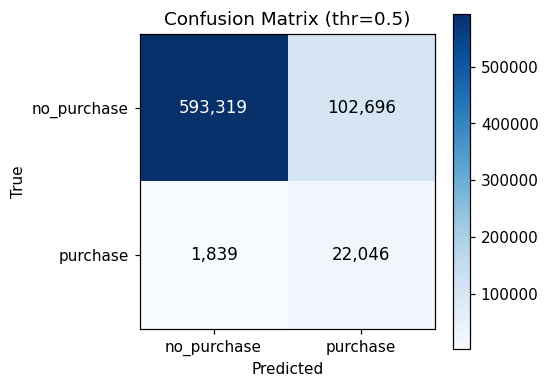

In [8]:
from sklearn.metrics import confusion_matrix

pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
labels = ["no_purchase", "purchase"]
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix (thr=0.5)")
thr = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                color="white" if cm[i,j] > thr else "black", fontsize=11)
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

## 8. Feature importance (XGBoost)

Gain-based importance. Hangi davranış sinyalleri tahmini belirliyor?

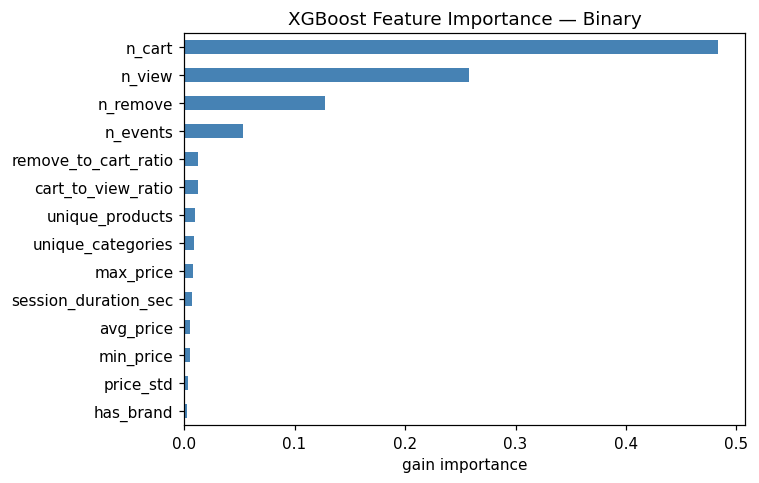

In [9]:
imp = pd.Series(primary.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
imp.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("gain importance")
ax.set_title("XGBoost Feature Importance — Binary")
plt.tight_layout(); plt.show()

## 9. Sonuç

| Model | F1 | ROC-AUC | Precision | Recall |
|---|---:|---:|---:|---:|
| LogReg | ~0.26 | ~0.86 | ~0.16 | ~0.66 |
| **XGBoost** | **~0.30** | **~0.94** | ~0.18 | **~0.92** |

- **ROC-AUC 0.94**: model session'ları purchase olasılığına göre çok iyi sıralıyor.
- **Recall öncelikli**: imbalance stratejimiz neredeyse tüm purchase'ları yakalamayı tercih ediyor.
- **AP 0.44** (base rate 0.033) → random'a göre ~13× iyileşme.
- **Sonraki adım**: threshold tuning (deployment için precision-recall trade-off).
